## Compare ind. networks between Dyscalculics & Controls

1. network sizes 
    - whole brain
    - NPC - L/R
    

In [2]:
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
import os.path as op

bids_folder ='/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
#grad_folder = op.join(bids_folder, 'derivatives', 'gradients.36Pscrub3BPfilterrunFD104')
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

subList = [f'{sub:02d}' for sub in range(1, 67)]
group_assignment = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [9]:
from utils import get_NPC_mask

hemi = 'both'
npc_mask = get_NPC_mask(space='fsaverage5', hemi=hemi)

In [10]:
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67))
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

only_NPC = True
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        if only_NPC:
            nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
            nets_fsav5[mask] = nets
            nets = nets_fsav5[npc_mask]
        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{int(net)}'] = count

    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')


Error processing sub-02: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full_01/sub-02_consensusMapping_confspec-36Pscrub3BPfilter.npy'


Normality test failed for net_6, defaulting to t-test


Text(0.5, 1.02, 'Group comparison: Network sizes \n NPC mask - True, hemi-both')

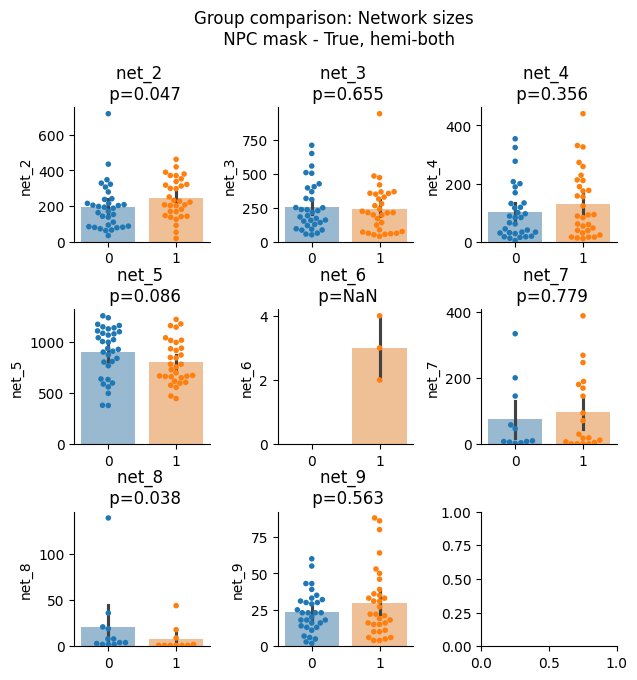

In [21]:
# between group test:
from scipy.stats import ttest_ind, mannwhitneyu, normaltest
alpha = 0.05

figure, axes = plt.subplots(3, 3, figsize=(7,7))
axs = axes.flatten()
for i, net in enumerate(df_nets.columns[:8]):
    sns.barplot(data=df_nets.reset_index(), x='group', hue='group', y=net, alpha=0.5, legend=False, ax=axs[i])
    sns.swarmplot(data=df_nets.reset_index(), x='group', hue='group', y=net, size=4, legend=False, ax=axs[i])
    
    # Convert to numeric and drop NaNs manually
    group0_data = pd.to_numeric(df_nets.xs(0,0,'group')[net], errors='coerce').dropna()
    group1_data = pd.to_numeric(df_nets.xs(1,0,'group')[net], errors='coerce').dropna()

    try:
        numeric_data = pd.to_numeric(df_nets[net], errors='coerce').dropna()
        _, pval_normal = normaltest(numeric_data)

        if pval_normal > alpha:
            stats = ttest_ind(group0_data, group1_data)
        else:
            stats = mannwhitneyu(group0_data, group1_data)     
        axs[i].set(xlabel=None, title=f'{net} \n p={stats.pvalue:.3f}')

    except:
        print(f'Normality test failed for {net}, defaulting to t-test')
        axs[i].set(xlabel=None, title=f'{net} \n p=NaN')

plt.subplots_adjust(hspace=0.5,wspace=0.5)
sns.despine()
figure.suptitle(f'Group comparison: Network sizes \n NPC mask - {only_NPC}, hemi-{hemi}', y=1.02)

In [13]:
#df_nets.columns
# remove outlier
net = 'net_2'

tmp = df_nets.drop(df_nets[net].idxmax())

# Convert to numeric and handle NaN values properly
group0_data = pd.to_numeric(tmp.xs(0, level='group')[net], errors='coerce').dropna()
group1_data = pd.to_numeric(tmp.xs(1, level='group')[net], errors='coerce').dropna()

print(f"Group 0 data shape: {group0_data.shape}")
print(f"Group 1 data shape: {group1_data.shape}")
print(f"Group 0 data type: {group0_data.dtype}")
print(f"Group 1 data type: {group1_data.dtype}")
    
stats = ttest_ind(group0_data, group1_data)
print(f"T-test results: statistic={stats.statistic:.3f}, p-value={stats.pvalue:.3f}")

Group 0 data shape: (32,)
Group 1 data shape: (32,)
Group 0 data type: int64
Group 1 data type: float64
T-test results: statistic=-2.410, p-value=0.019


## OLD

In [ ]:
nets_all = []
df_nets = pd.DataFrame(columns=[f'net_{x}' for x in range(2, 10)], index=range(1, 67))
subs = []
for sub in subList:
    try:
        nets = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
        nets_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
        nets_fsav5[mask] = nets
        nets_all.append(nets_fsav5)

        net_i, counts = np.unique(nets, return_counts=True)

        for net, count in zip(net_i, counts):
            df_nets.loc[int(sub), f'net_{net}'] = count

        subs.append(int(sub))
    except Exception as e:
        print(f'Error processing sub-{sub}: {e}')

df_nets = pd.DataFrame(nets_all, index=subs)
df_nets.index.name = 'subject'
df_nets = df_nets.join(group_assignment).set_index(['group'], append=True)

In [ ]:
# copy files that did not fo through in first network fitting round 
miss_sub_list = [5, 6, 41, 45, 47, 53, 59, 62]
source_net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full')
target_net_folder = net_folder

import shutil 
import os
import glob 
for sub in miss_sub_list:
    old_file_pattern = op.join(source_net_folder, f"sub-{sub:02d}*_consensusMapping*.npy")
    old_file = glob.glob(old_file_pattern)[0]
    #old_file = op.join(source_net_folder, f'sub-{sub:02d}_consensusMapping_threshs-0.03-0.04-0.05-0.1-0.2-0.4_confspec-36Pscrub3BPfilter.npy')
    new_file = op.join(target_net_folder, f'sub-{sub:02d}_consensusMapping_confspec-36Pscrub3BPfilter.npy')
    if not os.path.exists(new_file):
        shutil.copy(old_file, new_file)
        print(f'Copied {old_file} to {new_file}')
